In [73]:
import sklearn
import numpy as np

data = sklearn.datasets.load_wine()
X = data.data
y = data.target
y = (y == 0).astype(int)

scaler = sklearn.preprocessing.StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=10)

model = sklearn.linear_model.LogisticRegression(random_state=10)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

# print(y_pred)
# print(y_test)

# print(np.sum(y_pred == y_test))
# print(y_test.shape)

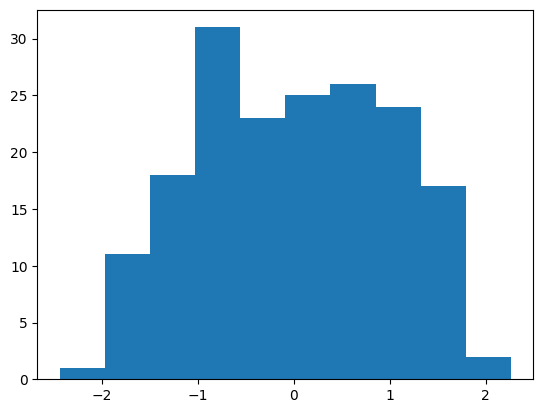

In [10]:
import matplotlib.pyplot as plt

plt.hist(X[:, 0])
plt.show()

In [127]:
y_pred = model.predict(X)
y_prob = model.predict_proba(X)

y_noisy = y.copy()

np.random.seed(10)
mask = np.random.rand(len(y_noisy)) <= 0.7
y_noisy[mask] = 1 - y_noisy[mask]


In [105]:
TP = np.sum((y_noisy == 1) & (y_pred == 1))
TN = np.sum((y_noisy == 0) & (y_pred == 0))
FP = np.sum((y_noisy == 0) & (y_pred == 1))
FN = np.sum((y_noisy == 1) & (y_pred == 0))

print(f'TP {TP}, TN {TN}, FP {FP}, FN {FN}')

TP 53, TN 104, FP 6, FN 15


In [128]:
acc = sklearn.metrics.accuracy_score(y_noisy, y_pred)
pre = sklearn.metrics.precision_score(y_noisy, y_pred)
recall = sklearn.metrics.recall_score(y_noisy, y_pred)

cm = sklearn.metrics.confusion_matrix(y_noisy, y_pred)
FP = cm[0, 1]
TN = cm[0, 0]

FRP = FP / (FP + TN)
print(f'acc {acc}, FRP {FRP}, recall {recall}, pre {pre}')

print(np.array([[TP, FP], [FN, TN]]))

acc 0.25842696629213485, FRP 0.5970149253731343, recall 0.17117117117117117, pre 0.3220338983050847
[[53 40]
 [15 27]]


auc:  0.2792792792792793


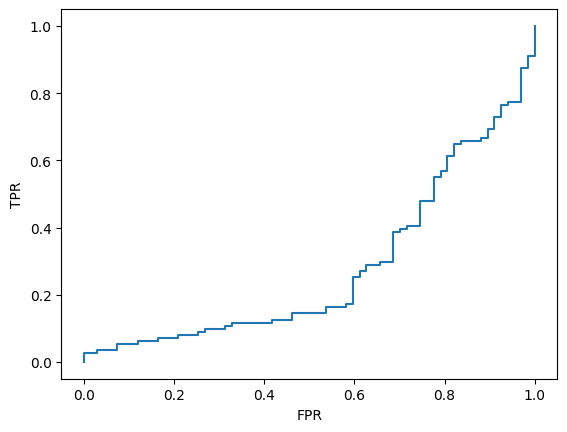

In [129]:
import matplotlib.pyplot as plt

fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_noisy, y_prob[:,1])
auc = sklearn.metrics.auc(fpr, tpr)
print('auc: ', auc)

plt.plot(fpr, tpr)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()
